# UMAP of the top 1% and 5% most variable genes


In [1]:
!pip -q install umap-learn

In [21]:
from pathlib import Path
from itertools import zip_longest
import csv, math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap.umap_ as umap

plt.rcParams['figure.dpi'] = 130

## Part I: RNA-seq

### Set paths and choose the input file series

- `SOURCE_MODE = "all"`: both `Batch*` and `AML_B*` **count** files.
- `SOURCE_MODE = "batch_only"`: only original `Batch*` files.
- `SOURCE_MODE = "aml_only"`: only `AML_B*` files.

In [3]:
# Mac local notebook / Colab connected to your Mac's local runtime:
RNASEQ_DIR = Path("/Users/rita/medgemma-fl/RNAseq")

META_PATH = RNASEQ_DIR / "TARGET_meta.txt"
OUTPUT_DIR = RNASEQ_DIR.parent / "outputs" / "rnaseq_umap"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_MODE = "all"  # "all", "batch_only", "aml_only"
MIN_COUNT = 10
MIN_SAMPLES = 10
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
RANDOM_STATE = 42

print("RNA-seq directory exists:", RNASEQ_DIR.is_dir())
print("Metadata file exists:", META_PATH.is_file())
if not RNASEQ_DIR.is_dir():
    raise FileNotFoundError(f"Cannot access {RNASEQ_DIR}; check the notebook runtime/path.")
if not META_PATH.is_file():
    raise FileNotFoundError(f"Cannot find {META_PATH}; check exact metadata filename.")

RNA-seq directory exists: True
Metadata file exists: True


### Discover count files and load both filename patterns

Only `RSEM_gene_count` files enter the count matrix. `RSEM_gene_TPM` files are intentionally skipped. `STRANDED` is preferred over `UNSTRANDED` for **duplicate sample IDs**.

In [4]:
COUNT_FILE_RE = re.compile(
    r'^WU-TARGET[-_](?P<source>Batch|AML_B)(?P<number>\d+)-'
    r'(?P<strand>STRANDED|UNSTRANDED)_RSEM_gene_count(?:\..*)?\.txt$',
    re.IGNORECASE,
)

def normalize_sample_id(sample_id):
    return str(sample_id).strip().replace('.', '-')

def load_diagnosis_map(meta_path):
    diagnoses = {}
    with open(meta_path, newline='') as handle:
        reader = csv.DictReader(handle, delimiter='\t')
        if not reader.fieldnames or 'Sample' not in reader.fieldnames or 'Dx' not in reader.fieldnames:
            raise ValueError(f"Expected Sample and Dx columns in {meta_path}; found {reader.fieldnames}")
        for row in reader:
            sid = normalize_sample_id(row['Sample'])
            dx = (row['Dx'] or '').strip().upper()
            if sid and dx and dx != 'NA':
                diagnoses[sid] = dx
    return diagnoses

def parse_count_filename(filename):
    match = COUNT_FILE_RE.fullmatch(filename)
    if match is None:
        return None
    source = 'AML' if match.group('source').upper() == 'AML_B' else 'Batch'
    return source, int(match.group('number')), match.group('strand').upper()

def discover_count_files(rnaseq_dir, source_mode='all'):
    if source_mode not in ('all', 'batch_only', 'aml_only'):
        raise ValueError(f"Unknown SOURCE_MODE: {source_mode}")
    selected = []
    for path in rnaseq_dir.glob('*.txt'):
        parsed = parse_count_filename(path.name)
        if parsed is None:
            continue
        source, number, strand = parsed
        if source_mode == 'batch_only' and source != 'Batch':
            continue
        if source_mode == 'aml_only' and source != 'AML':
            continue
        # When a sample occurs in several files, prefer original Batch series,
        # then STRANDED, then low batch number. Duplicates are disclosed below.
        selected.append((0 if source == 'Batch' else 1,
                         0 if strand == 'STRANDED' else 1,
                         number, source, strand, path))
    return sorted(selected)

def read_count_table(path):
    with open(path, newline='') as handle:
        reader = csv.reader(handle, delimiter='\t')
        header = next(reader)
        if len(header) < 5:
            raise ValueError(f"Expected four gene annotation fields plus samples in {path}")
        samples = [normalize_sample_id(x) for x in header[4:]]
        gene_ids, gene_symbols, bio_types, rows = [], [], [], []
        for row in reader:
            if len(row) < 4 + len(samples):
                raise ValueError(f"Unexpected short count row in {path}")
            gene_ids.append(row[0])
            gene_symbols.append(row[1] or row[0])
            bio_types.append(row[2])
            rows.append([float(v) if v not in ('', 'NA') else 0.0
                         for v in row[4:4+len(samples)]])
    return gene_ids, gene_symbols, bio_types, samples, np.asarray(rows, dtype=np.float64)

count_files = discover_count_files(RNASEQ_DIR, SOURCE_MODE)
file_inventory = pd.DataFrame([
    {'filename': row[-1].name, 'series': row[3], 'strand': row[4],
     'batch': row[2], 'size_MiB': round(row[-1].stat().st_size / 2**20, 2)}
    for row in count_files
])
print(f"Found {len(count_files)} RSEM count files (SOURCE_MODE={SOURCE_MODE}); TPM files are excluded")
if not count_files:
    raise FileNotFoundError(f"No matching count files under {RNASEQ_DIR}")
display(file_inventory)

Found 23 RSEM count files (SOURCE_MODE=all); TPM files are excluded


,filename,series,strand,batch,size_MiB
0,WU-TARGET-Batch01-STRANDED_RSEM_gene_count.202...,Batch,STRANDED,1,29.29
1,WU-TARGET-Batch02-STRANDED_RSEM_gene_count.202...,Batch,STRANDED,2,29.05
2,WU-TARGET-Batch03-STRANDED_RSEM_gene_count.202...,Batch,STRANDED,3,28.88
3,WU-TARGET-Batch04-STRANDED_RSEM_gene_count.202...,Batch,STRANDED,4,28.85
4,WU-TARGET-Batch05-STRANDED_RSEM_gene_count.202...,Batch,STRANDED,5,28.78
5,WU-TARGET-Batch06-STRANDED_RSEM_gene_count.202...,Batch,STRANDED,6,28.94
6,WU-TARGET-Batch07-STRANDED_RSEM_gene_count.202...,Batch,STRANDED,7,29.71
7,WU-TARGET-Batch08-STRANDED_RSEM_gene_count.202...,Batch,STRANDED,8,30.13
8,WU-TARGET-Batch09-STRANDED_RSEM_gene_count.202...,Batch,STRANDED,9,14.62
9,WU-TARGET-Batch01-UNSTRANDED_RSEM_gene_count.2...,Batch,UNSTRANDED,1,30.36


In [5]:
def merge_count_matrices(file_entries):
    seen = set()
    sample_ids, source_batches, sources, provenance_files = [], [], [], []
    duplicates = []
    count_blocks = []
    gene_ids = gene_symbols = bio_types = None

    for _, _, number, source, strand, path in file_entries:
        f_ids, f_symbols, f_bio, f_samples, f_counts = read_count_table(path)
        if gene_ids is None:
            gene_ids, gene_symbols, bio_types = f_ids, f_symbols, f_bio
        elif f_ids != gene_ids:
            raise ValueError(
                f"Gene IDs/order differ between count files; cannot safely concatenate: {path.name}. "
                "Try SOURCE_MODE='batch_only' or 'aml_only' to inspect each series separately; "
                "harmonize gene IDs/annotation before combining."
            )

        kept_indices = []
        for j, sid in enumerate(f_samples):
            if sid in seen:
                duplicates.append((sid, path.name))
                continue
            seen.add(sid)
            kept_indices.append(j)
            sample_ids.append(sid)
            source_batches.append(f"AML_B{number}" if source == 'AML' else f"Batch{number:02d}")
            sources.append(source)
            provenance_files.append(path.name)
        if kept_indices:
            count_blocks.append(f_counts[:, kept_indices])
        print(f"{path.name}: retained {len(kept_indices)} / {len(f_samples)} unique samples")

    if not count_blocks:
        raise ValueError('No unique samples were found.')
    if duplicates:
        print(f"WARNING: {len(duplicates)} repeated sample occurrences were skipped. "
              "Inspect duplicate_sample_occurrences.tsv before treating the combined cohort as validated.")
        pd.DataFrame(duplicates, columns=['sample_id', 'skipped_file']).to_csv(
            OUTPUT_DIR / 'duplicate_sample_occurrences.tsv', sep='\t', index=False)
    else:
        print('No repeated sample IDs across the selected count files.')

    return {
        'gene_ids': np.asarray(gene_ids),
        'gene_symbols': np.asarray(gene_symbols),
        'bio_types': np.asarray(bio_types),
        'sample_ids': np.asarray(sample_ids),
        'source_batches': np.asarray(source_batches),
        'sources': np.asarray(sources),
        'provenance_files': np.asarray(provenance_files),
        'counts': np.concatenate(count_blocks, axis=1),
    }

In [6]:
diagnosis_map = load_diagnosis_map(META_PATH)
merged = merge_count_matrices(count_files)
counts = merged['counts']

sample_meta = pd.DataFrame({
    'sample_id': merged['sample_ids'],
    'batch': merged['source_batches'],
    'source_group': merged['sources'],
    'input_file': merged['provenance_files'],
    'diagnosis': [diagnosis_map.get(sid, 'UNKNOWN') for sid in merged['sample_ids']],
})
print('Raw gene-count matrix shape (genes × samples):', counts.shape)
print('Samples lacking a matched Dx label:', (sample_meta.diagnosis == 'UNKNOWN').sum())
display(sample_meta['source_group'].value_counts().rename('n_samples').to_frame())
display(sample_meta['diagnosis'].value_counts().rename('n_samples').to_frame())
display(sample_meta['batch'].value_counts().sort_index().rename('n_samples').to_frame())

WU-TARGET-Batch01-STRANDED_RSEM_gene_count.2021-08-03_08-38-51.txt: retained 100 / 100 unique samples
WU-TARGET-Batch02-STRANDED_RSEM_gene_count.2021-08-03_21-30-36.txt: retained 100 / 100 unique samples
WU-TARGET-Batch03-STRANDED_RSEM_gene_count.2021-08-04_05-20-35.txt: retained 100 / 100 unique samples
WU-TARGET-Batch04-STRANDED_RSEM_gene_count.2021-08-04_01-44-47.txt: retained 100 / 100 unique samples
WU-TARGET-Batch05-STRANDED_RSEM_gene_count.2021-08-04_01-38-51.txt: retained 100 / 100 unique samples
WU-TARGET-Batch06-STRANDED_RSEM_gene_count.2021-08-06_11-45-47.txt: retained 100 / 100 unique samples
WU-TARGET-Batch07-STRANDED_RSEM_gene_count.2021-08-04_23-27-24.txt: retained 100 / 100 unique samples
WU-TARGET-Batch08-STRANDED_RSEM_gene_count.2021-08-04_21-26-02.txt: retained 100 / 100 unique samples
WU-TARGET-Batch09-STRANDED_RSEM_gene_count.2021-08-04_22-05-45.txt: retained 44 / 44 unique samples
WU-TARGET-Batch01-UNSTRANDED_RSEM_gene_count.2021-08-05_03-51-00.txt: retained 100 /

,n_samples
source_group,
AML,3226
Batch,1147


,n_samples
diagnosis,
UNKNOWN,3278
ALL,499
NBL,161
WT,136
MPAL,114
OS,87
RT,70
AML,15
CCSK,13


,n_samples
batch,
AML_B1,300
AML_B10,300
AML_B11,227
AML_B2,300
AML_B3,300
AML_B4,300
AML_B5,300
AML_B6,300
AML_B7,299


### Filter expressed protein-coding genes

Top 1% and top 5% are computed **within the eligible gene set**.


In [7]:
bio_mask = merged['bio_types'] == 'protein_coding'
expressed_mask = (counts >= MIN_COUNT).sum(axis=1) >= MIN_SAMPLES
eligible_mask = bio_mask & expressed_mask
n_eligible = int(eligible_mask.sum())

print(f"Total genes: {counts.shape[0]:,}")
print(f"Eligible expressed protein-coding genes: {n_eligible:,}")
print(f"Top 1%: {math.ceil(n_eligible*0.01):,} genes")
print(f"Top 5%: {math.ceil(n_eligible*0.05):,} genes")

Total genes: 60,754
Eligible expressed protein-coding genes: 19,166
Top 1%: 192 genes
Top 5%: 959 genes


### Illustrative Python TMM → log2(CPM + 1)

This uses the **custom TMM approximation** from your earlier preprocessing script, which has not been established as numerically identical to edgeR. For reporting quantitative expression analyses or publishing figures, run and validate against edgeR `calcNormFactors(method="TMM")` instead; particularly important for RSEM estimated counts and low-abundance genes.

In [8]:
def tmm_norm_factors(counts, log_ratio_trim=0.3, sum_trim=0.05):
    library_sizes = np.maximum(counts.sum(axis=0), 1.0)
    upper_quartiles = np.percentile(counts, 75, axis=0)
    ref_idx = int(np.argmin(np.abs(upper_quartiles - np.mean(upper_quartiles))))
    ref_counts = counts[:, ref_idx]
    ref_lib = library_sizes[ref_idx]
    factors = np.ones(counts.shape[1], dtype=np.float64)

    for sample_idx in range(counts.shape[1]):
        if sample_idx == ref_idx:
            continue
        obs = counts[:, sample_idx]; obs_lib = library_sizes[sample_idx]
        keep = (obs > 0) & (ref_counts > 0)
        if int(keep.sum()) < 50:
            continue
        obs_k, ref_k = obs[keep], ref_counts[keep]
        log_r = np.log2((obs_k/obs_lib)/(ref_k/ref_lib))
        abs_e = 0.5*np.log2((obs_k/obs_lib)*(ref_k/ref_lib))
        var = (obs_lib-obs_k)/(obs_lib*obs_k) + (ref_lib-ref_k)/(ref_lib*ref_k)
        finite = np.isfinite(log_r) & np.isfinite(abs_e) & np.isfinite(var) & (var > 0)
        log_r, abs_e, var = log_r[finite], abs_e[finite], var[finite]
        if log_r.size < 50:
            continue
        n=log_r.size
        lo_m, hi_m = int(np.floor(n*log_ratio_trim)), int(np.ceil(n*(1-log_ratio_trim)))
        lo_a, hi_a = int(np.floor(n*sum_trim)), int(np.ceil(n*(1-sum_trim)))
        order_m, order_a = np.argsort(log_r), np.argsort(abs_e)
        keep_m=np.zeros(n,bool); keep_a=np.zeros(n,bool)
        keep_m[order_m[lo_m:hi_m]]=True; keep_a[order_a[lo_a:hi_a]]=True
        selected = keep_m & keep_a
        if not np.any(selected):
            continue
        weights = 1.0/var[selected]
        factors[sample_idx] = 2.0**(np.sum(weights*log_r[selected])/np.sum(weights))

    return factors / np.exp(np.mean(np.log(np.maximum(factors, 1e-8))))

def log2_tmm_cpm(counts):
    factors = tmm_norm_factors(counts)
    effective_lib = np.maximum(counts.sum(axis=0)*factors, 1.0)
    cpm = counts/effective_lib*1e6
    return np.log2(cpm + 1.0), factors

log_cpm, tmm_factors = log2_tmm_cpm(counts)
print(f"TMM factors: min={tmm_factors.min():.3f}, median={np.median(tmm_factors):.3f}, max={tmm_factors.max():.3f}")

TMM factors: min=0.026, median=1.067, max=2.217


### Select top 1% and top 5% most variable genes

Variance is calculated across samples on normalized log2-CPM. No diagnosis label is used here.


In [9]:

eligible_indices = np.flatnonzero(eligible_mask)
eligible_variance = np.var(log_cpm[eligible_indices, :], axis=1)
ranked_gene_indices = eligible_indices[np.argsort(eligible_variance)[::-1]]

n_top_1 = max(1, math.ceil(n_eligible*0.01))
n_top_5 = max(1, math.ceil(n_eligible*0.05))
top1_idx = ranked_gene_indices[:n_top_1]
top5_idx = ranked_gene_indices[:n_top_5]

def hvg_table(indices):
    return pd.DataFrame({
        'gene_id': merged['gene_ids'][indices],
        'gene_symbol': merged['gene_symbols'][indices],
        'variance': np.var(log_cpm[indices, :], axis=1),
    })

top1_genes = hvg_table(top1_idx)
top5_genes = hvg_table(top5_idx)
display(top1_genes.head(20))

top1_genes.to_csv(OUTPUT_DIR/'top_1pct_variable_genes.tsv', sep='\t', index=False)
top5_genes.to_csv(OUTPUT_DIR/'top_5pct_variable_genes.tsv', sep='\t', index=False)


,gene_id,gene_symbol,variance
0,ENSG00000005381.7,MPO,18.249973
1,ENSG00000206047.2,DEFA1,17.009042
2,ENSG00000206172.8,HBA1,15.991407
3,ENSG00000244734.4,HBB,15.338874
4,ENSG00000196565.15,HBG2,14.156799
5,ENSG00000188536.13,HBA2,14.080598
6,ENSG00000284931.1,AC104389.5,13.863059
7,ENSG00000067048.17,DDX3Y,13.652102
8,ENSG00000012223.12,LTF,13.452638
9,ENSG00000197561.7,ELANE,13.142332


### Plot UMAP

For each gene set: samples × selected genes → UMAP 2D directly from log2(CPM + 1). No diagnosis, sample origin, or batch metadata is supplied to UMAP.

In [11]:
def run_umap(log_cpm, gene_indices, random_state=42):
    # UMAP requires samples × genes, while log_cpm stores genes × samples.
    X = log_cpm[gene_indices, :].T
    print(f"Direct UMAP input: {X.shape[0]} samples × {X.shape[1]} genes")
    if X.shape[0] < 4:
        raise ValueError('Not enough samples for UMAP')
    reducer = umap.UMAP(
        n_neighbors=min(UMAP_N_NEIGHBORS, X.shape[0]-1),
        min_dist=UMAP_MIN_DIST,
        n_components=2,
        metric='euclidean',
        random_state=random_state,
    )
    return reducer.fit_transform(X)

umap_top1 = run_umap(log_cpm, top1_idx, RANDOM_STATE)
umap_top5 = run_umap(log_cpm, top5_idx, RANDOM_STATE)

Direct UMAP input: 4373 samples × 192 genes


/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Direct UMAP input: 4373 samples × 959 genes


/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Plot each embedding by diagnosis, sample batch, and file series

The 1% or 5% UMAP coordinates stay **identical** when changing only the plotting colors. Color by `source_group` to check whether `AML_B*` and `Batch*` form source-specific clusters.

In [12]:
def plot_embedding(embedding, metadata, color_col, title, output_path):
    fig, ax = plt.subplots(figsize=(9, 7))
    categories = sorted(metadata[color_col].astype(str).unique())
    vals = metadata[color_col].astype(str).values
    for category in categories:
        mask = vals == category
        ax.scatter(embedding[mask,0], embedding[mask,1], s=24, alpha=0.75, label=category)
    ax.set_title(title)
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
    ax.legend(title=color_col.capitalize(), bbox_to_anchor=(1.02,1), loc='upper left', frameon=False)
    fig.tight_layout()
    fig.savefig(output_path, bbox_inches='tight')
    plt.show()

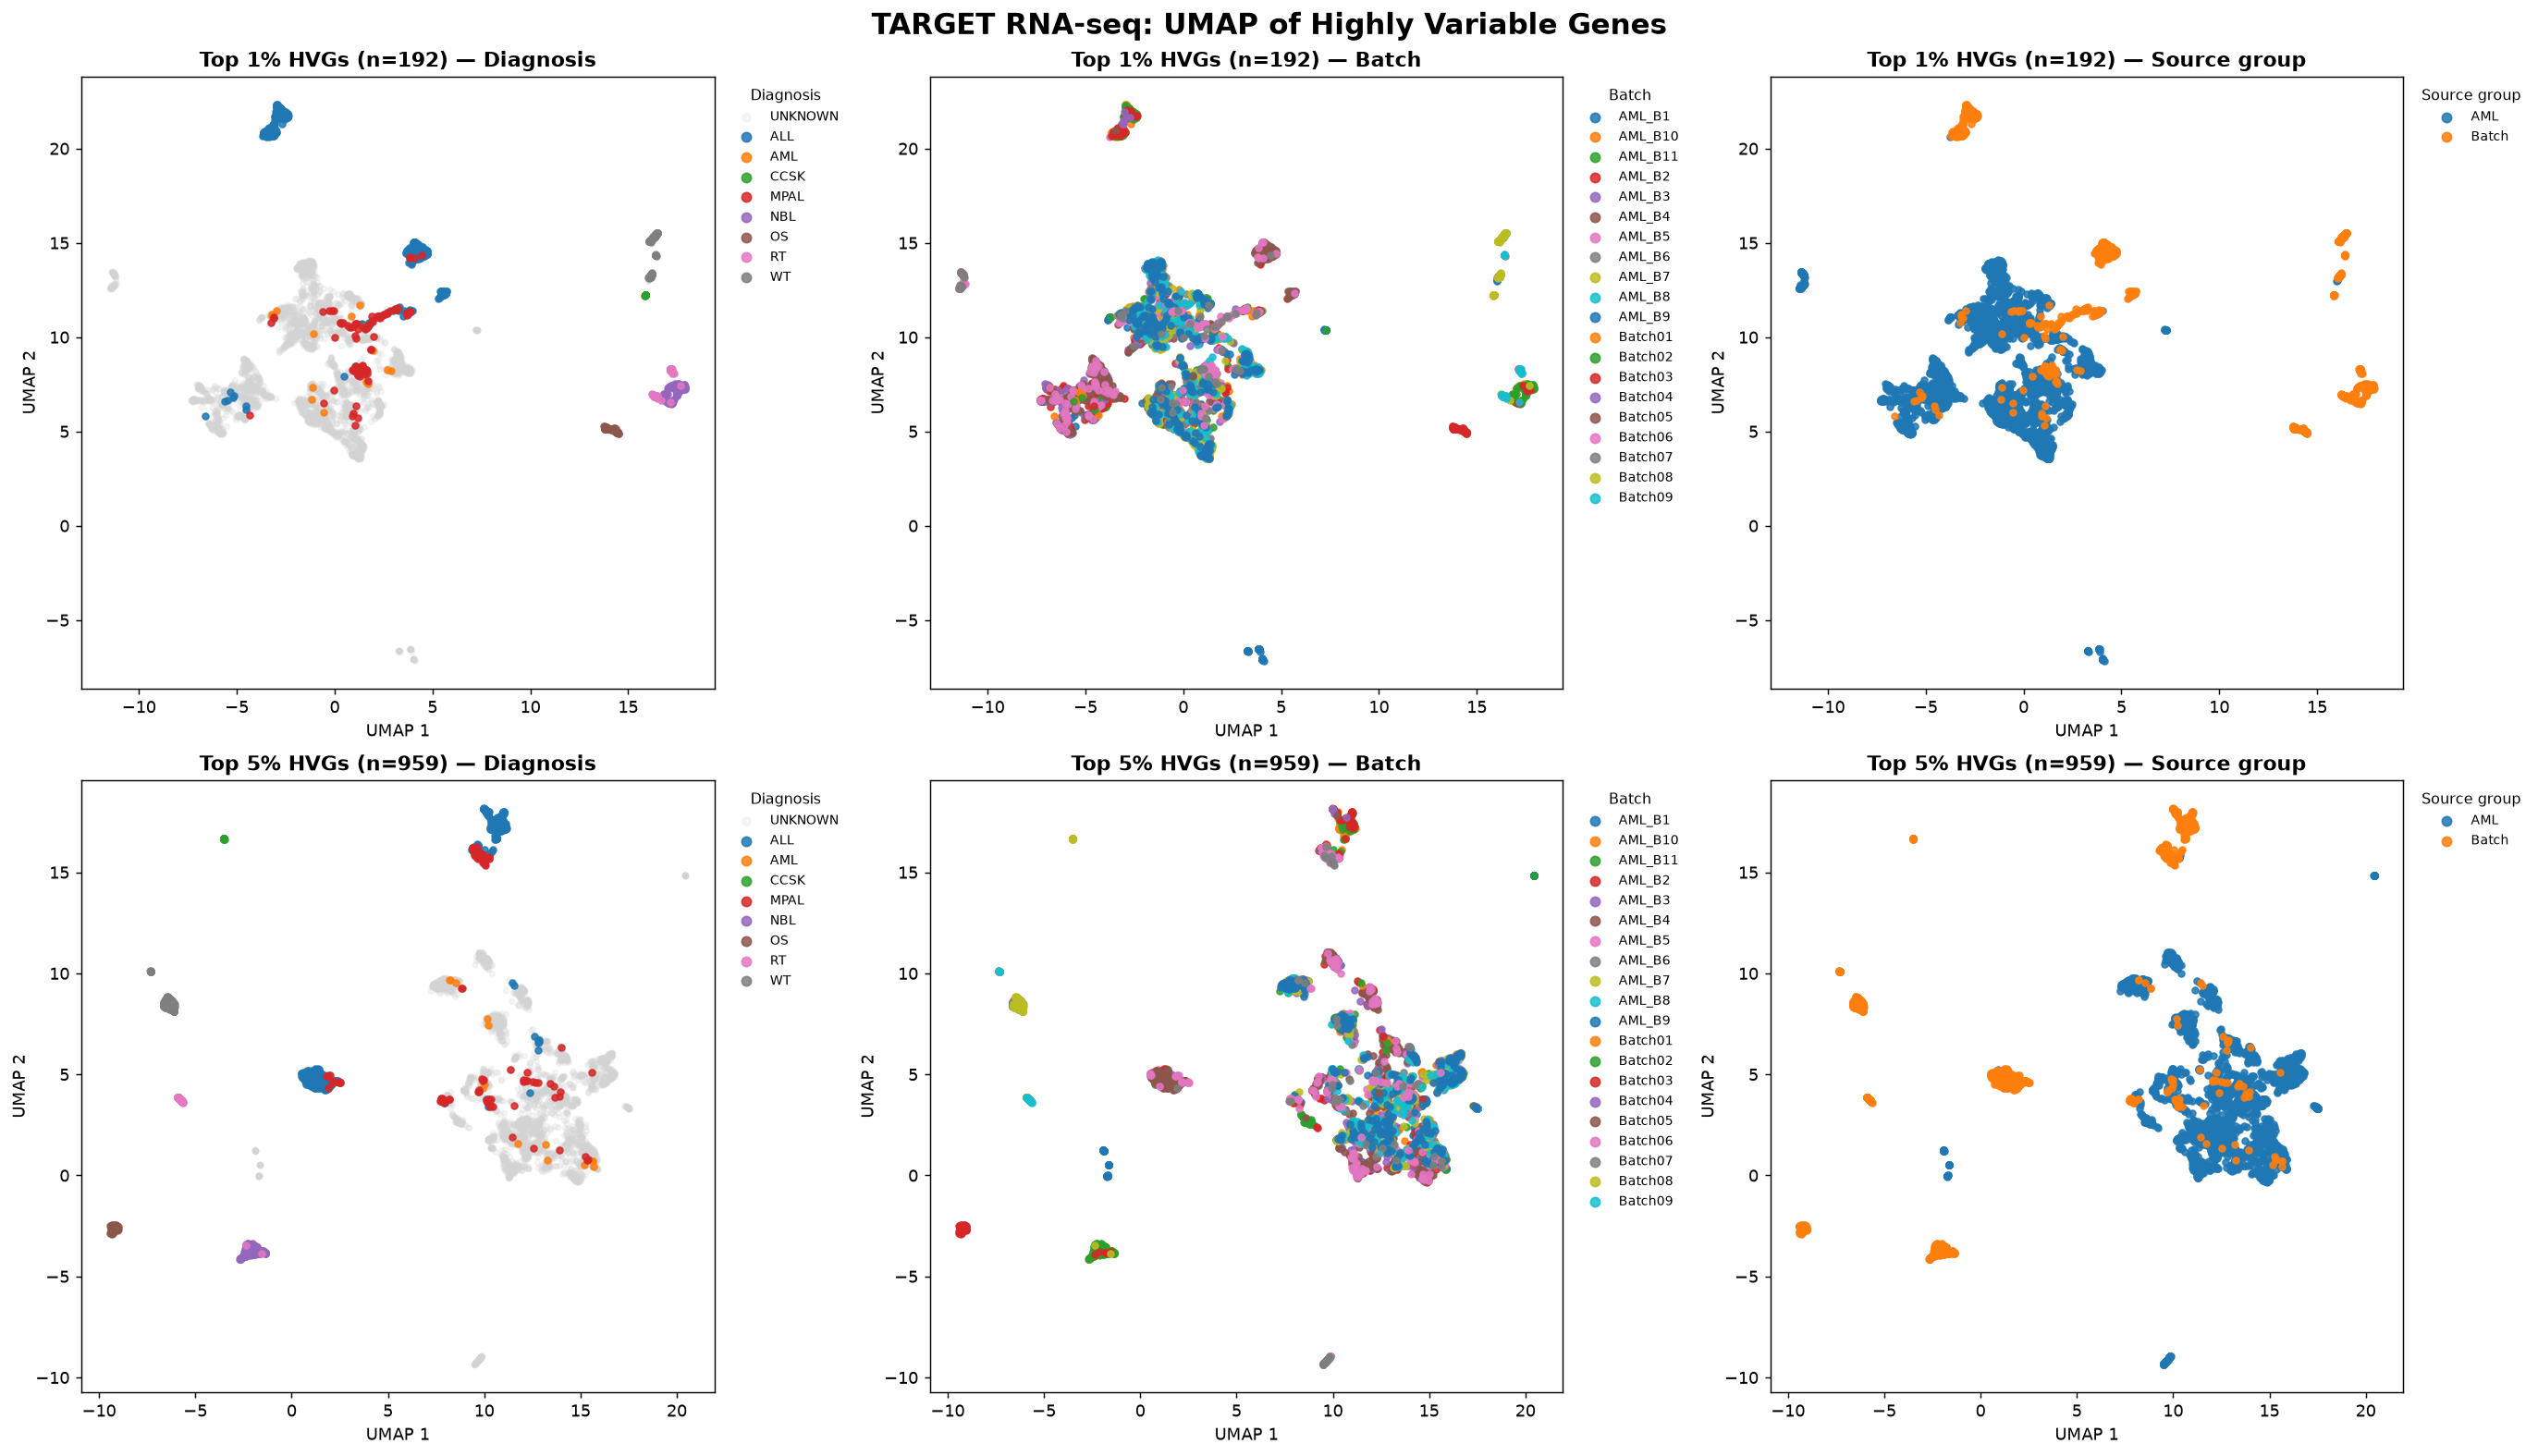

In [13]:
# 2 rows × 3 columns
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(21, 12),
    constrained_layout=True
)

rows = [
    ("1", umap_top1, top1_idx),
    ("5", umap_top5, top5_idx),
]

color_cols = [
    ("diagnosis", "Diagnosis"),
    ("batch", "Batch"),
    ("source_group", "Source group"),
]

for row_idx, (pct, embedding, gene_idx) in enumerate(rows):

    for col_idx, (color_col, color_title) in enumerate(color_cols):

        ax = axes[row_idx, col_idx]

        values = sample_meta[color_col].fillna("UNKNOWN").astype(str).values
        categories = sorted(
            set(values),
            key=lambda x: (x != "UNKNOWN", x)
)

        for category in categories:

            mask = values == category

            ax.scatter(
                embedding[mask, 0],
                embedding[mask, 1],
                s=10 if category == "UNKNOWN" else 14,
                alpha=0.2 if category == "UNKNOWN" else 0.85,
                color="lightgray" if category == "UNKNOWN" else None,
                label=category,
                rasterized=True,
                zorder=1 if category == "UNKNOWN" else 2
            )

        ax.set_title(
            f"Top {pct}% HVGs (n={len(gene_idx)}) — {color_title}",
            fontsize=12,
            fontweight="bold"
        )

        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")

        ax.legend(
            title=color_title,
            loc="upper left",
            bbox_to_anchor=(1.01, 1),
            fontsize=8,
            title_fontsize=9,
            frameon=False,
            markerscale=1.5
        )

fig.suptitle(
    "TARGET RNA-seq: UMAP of Highly Variable Genes",
    fontsize=17,
    fontweight="bold"
)

# Save one combined figure
fig.savefig(
    OUTPUT_DIR / "TARGET_RNAseq_UMAP_2x3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# for pct, embed, gene_idx in [('1', umap_top1, top1_idx), ('5', umap_top5, top5_idx)]:
#     for color_col in ('diagnosis', 'batch', 'source_group'):
#         plot_embedding(
#             embed, sample_meta, color_col,
#             f"TARGET RNA-seq: UMAP — Top {pct}% variable genes (n={len(gene_idx)}) — {color_col}",
#             OUTPUT_DIR / f"umap_top{pct}pct_by_{color_col}.png",
#         )

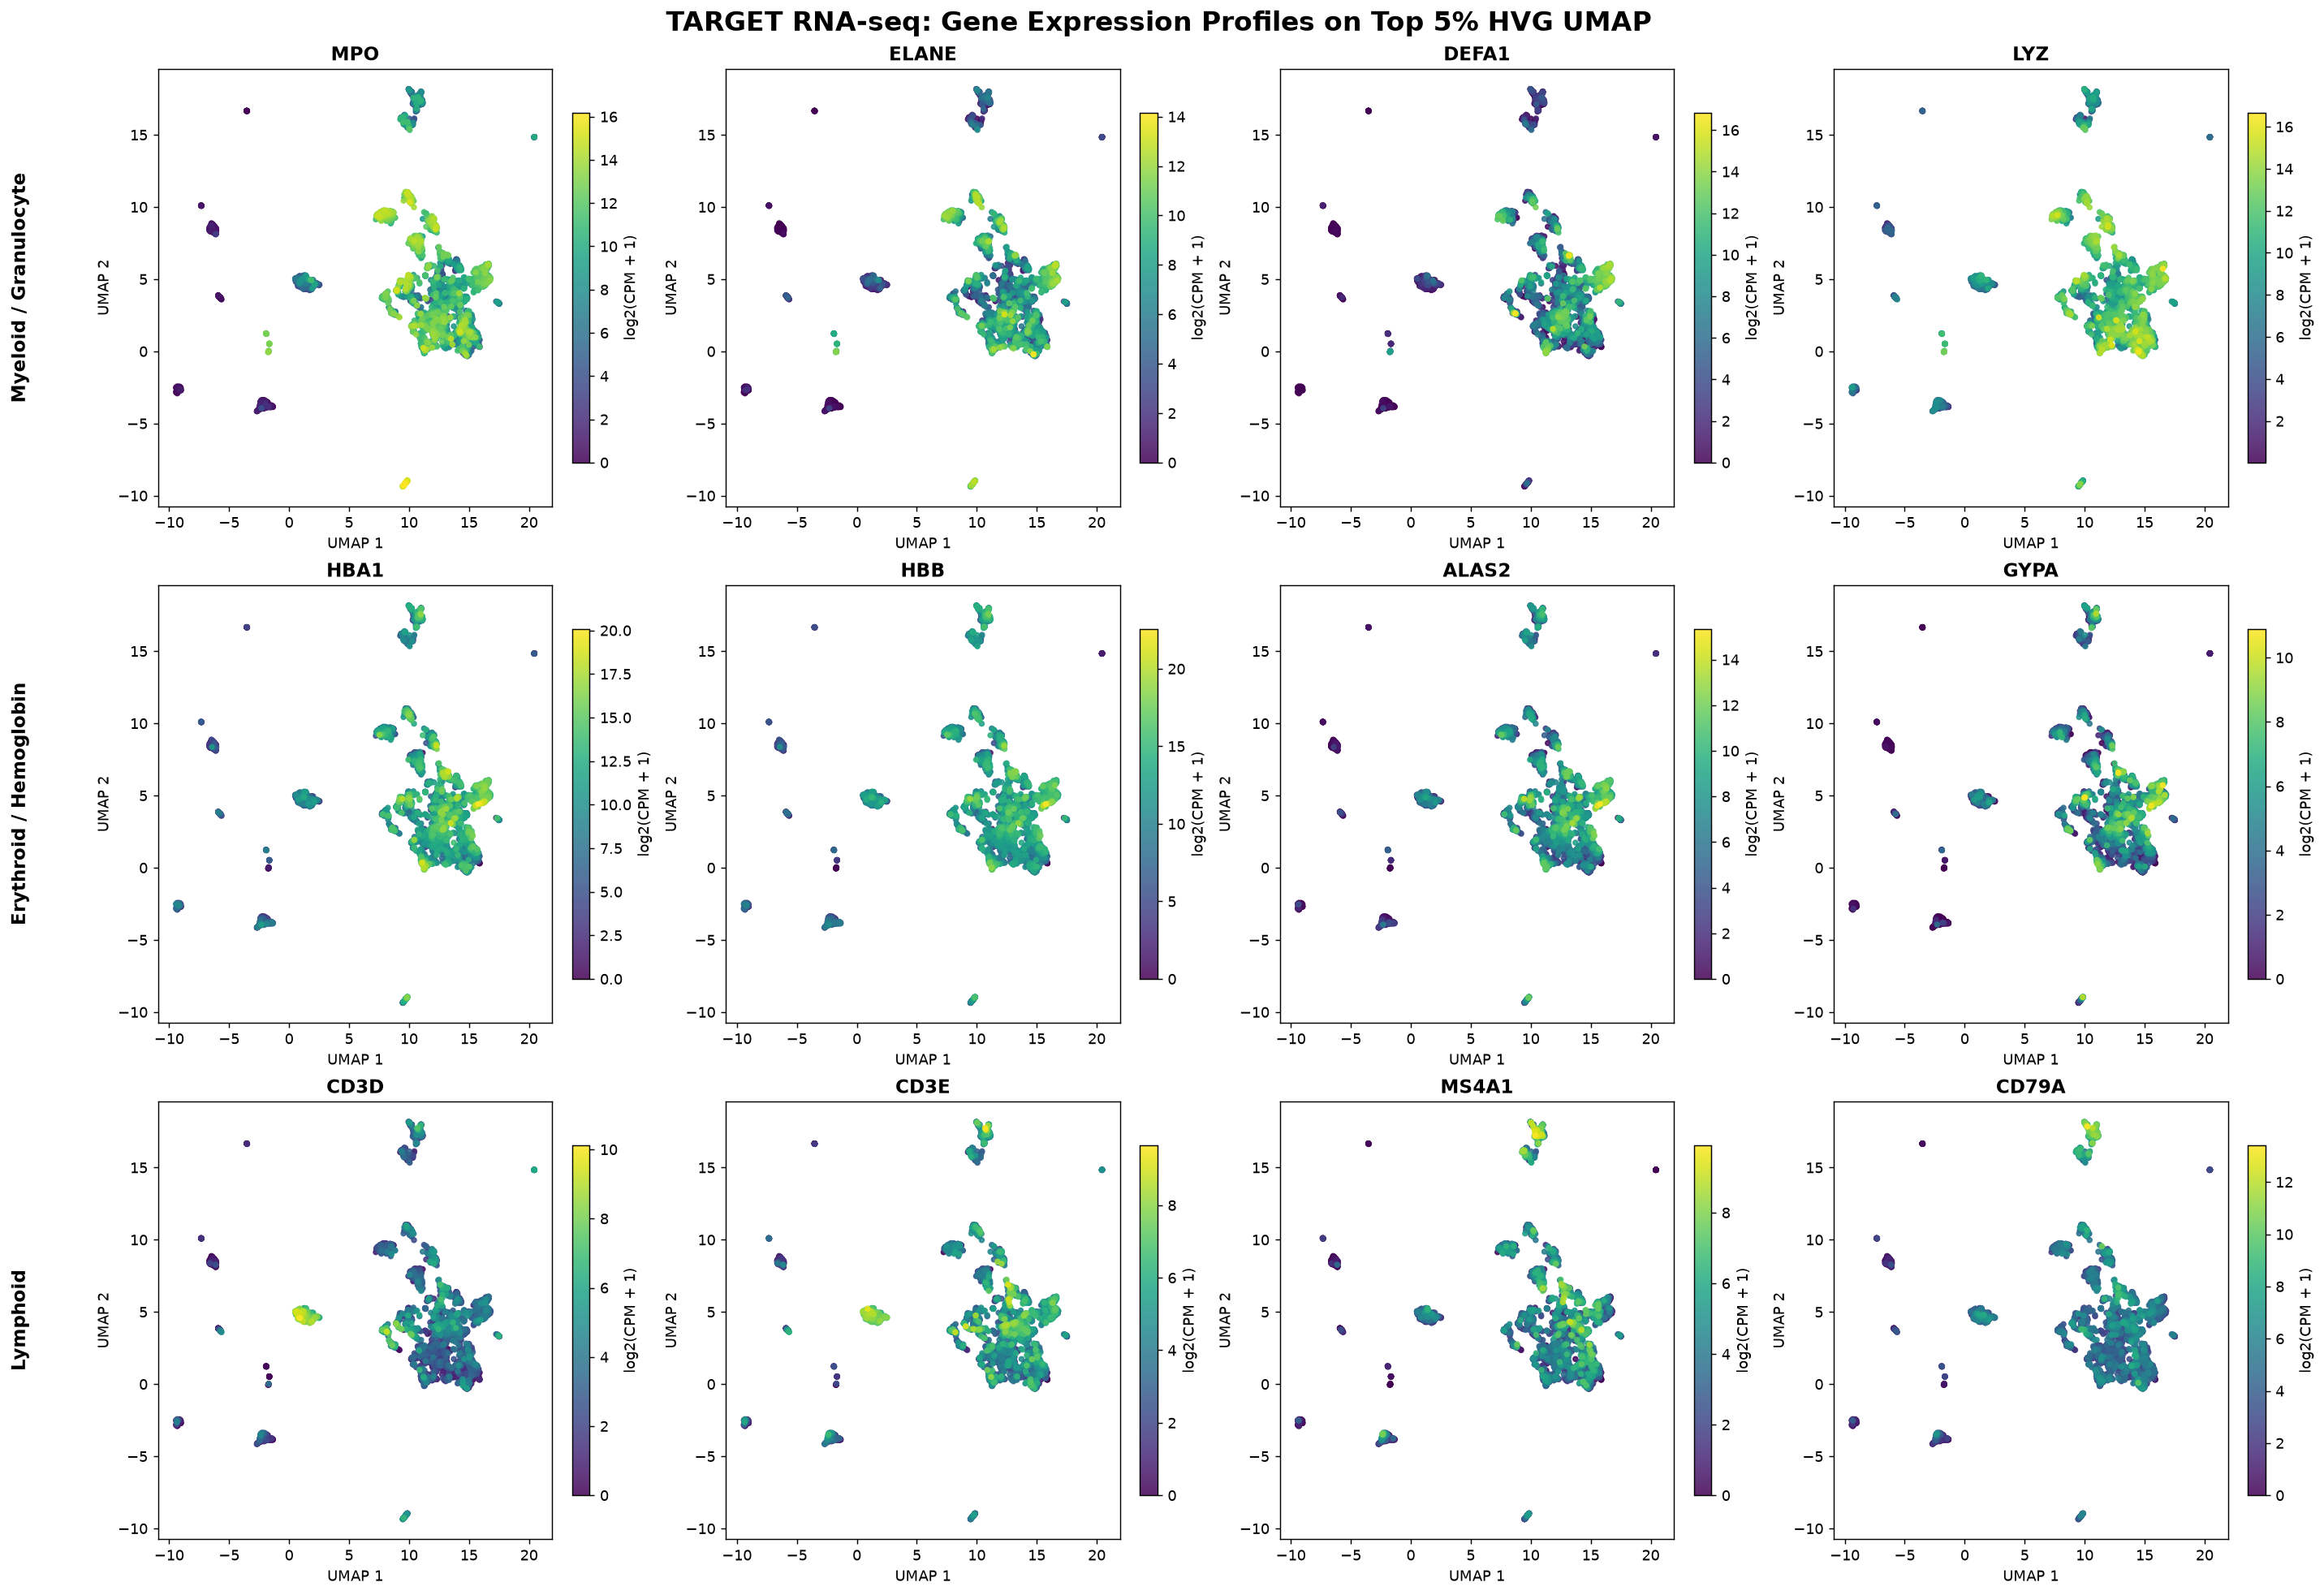

In [14]:
# TARGET RNA-seq: Gene Expression UMAP — Top 5% HVGs
# 12 genes: Myeloid / Erythroid / Lymphoid markers

# Select genes from different biological categories
gene_groups = {
    "Myeloid / Granulocyte": [
        "MPO", "ELANE", "DEFA1", "LYZ"
    ],
    "Erythroid / Hemoglobin": [
        "HBA1", "HBB", "ALAS2", "GYPA"
    ],
    "Lymphoid": [
        "CD3D", "CD3E", "MS4A1", "CD79A"
    ],
}

# Existing Top 5% HVG UMAP coordinates
embedding = umap_top5

# Original gene expression data
gene_symbols = np.asarray(
    merged["gene_symbols"]
).astype(str)

# Verify sample alignment
assert embedding.shape[0] == log_cpm.shape[1], (
    "UMAP coordinates and expression matrix have "
    "different sample counts."
)

assert embedding.shape[0] == len(sample_meta), (
    "UMAP coordinates and sample metadata have "
    "different sample counts."
)

# Create 3 rows × 4 columns
fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(22, 15),
    constrained_layout=True
)

gene_symbols_upper = np.char.upper(gene_symbols)

for row_idx, (group_name, genes) in enumerate(
    gene_groups.items()
):

    for col_idx, gene in enumerate(genes):

        ax = axes[row_idx, col_idx]

        # Find the gene in the original expression matrix
        gene_indices = np.flatnonzero(
            gene_symbols_upper == gene.upper()
        )

        if len(gene_indices) == 0:

            ax.text(
                0.5,
                0.5,
                f"{gene} not found",
                ha="center",
                va="center",
                transform=ax.transAxes
            )

            ax.set_axis_off()
            continue

        # If multiple rows share the gene symbol,
        # select the row with the highest expression variance
        if len(gene_indices) > 1:

            gene_variances = np.var(
                log_cpm[gene_indices, :],
                axis=1
            )

            gene_idx = gene_indices[
                np.argmax(gene_variances)
            ]

        else:

            gene_idx = gene_indices[0]

        # Expression across all TARGET samples
        expression = log_cpm[gene_idx, :]

        # Draw low-expression samples first
        order = np.argsort(expression)

        scatter = ax.scatter(
            embedding[order, 0],
            embedding[order, 1],
            c=expression[order],
            cmap="viridis",
            s=10,
            alpha=0.85,
            rasterized=True
        )

        ax.set_title(
            f"{gene}",
            fontsize=13,
            fontweight="bold"
        )

        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")

        fig.colorbar(
            scatter,
            ax=ax,
            label="log2(CPM + 1)",
            shrink=0.8
        )

    # Label the biological category for each row
    axes[row_idx, 0].annotate(
        group_name,
        xy=(-0.35, 0.5),
        xycoords="axes fraction",
        rotation=90,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold"
    )

# Title and save
fig.suptitle(
    "TARGET RNA-seq: Gene Expression Profiles "
    "on Top 5% HVG UMAP",
    fontsize=18,
    fontweight="bold"
)

fig.savefig(
    OUTPUT_DIR / "TARGET_Gene_Expression_UMAP_3x4.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Save UMAP coordinates for outlier inspection

In [ ]:
coords_top1 = sample_meta.copy()
coords_top1['UMAP1'] = umap_top1[:,0]; coords_top1['UMAP2'] = umap_top1[:,1]
coords_top1.to_csv(OUTPUT_DIR/'umap_top1pct_coordinates.tsv', sep='\t', index=False)

coords_top5 = sample_meta.copy()
coords_top5['UMAP1'] = umap_top5[:,0]; coords_top5['UMAP2'] = umap_top5[:,1]
coords_top5.to_csv(OUTPUT_DIR/'umap_top5pct_coordinates.tsv', sep='\t', index=False)

print('Saved outputs to:', OUTPUT_DIR.resolve())

Saved outputs to: /Users/rita/medgemma-fl/outputs/rnaseq_umap


---

## Part II: PCGP

### Download the count file and set the local path

In [16]:
PCGP_DIR = Path('/Users/rita/medgemma-fl/PCGP')
PCGP_OUTPUT_DIR = Path('/Users/rita/medgemma-fl/outputs/pcgp_umap')

if not PCGP_DIR.is_dir():
    raise FileNotFoundError(
        f'PCGP folder not found: {PCGP_DIR}\n'
        'Download the PCGP gene_count .txt from DNAnexus and edit PCGP_DIR.'
    )

pcgp_count_files = sorted(
    p for p in PCGP_DIR.glob('*.txt')
    if ('PCGP' in p.name.upper()
        and 'RSEM_GENE_COUNT' in p.name.upper()
        and 'TPM' not in p.name.upper())
)

print(f'PCGP count files: {len(pcgp_count_files)}')
for path in pcgp_count_files:
    print(f'  {path.name} ({path.stat().st_size / 2**20:.1f} MiB)')

if not pcgp_count_files:
    raise FileNotFoundError(
        'No PCGP RSEM gene_count .txt file found. '
        f'Check folder and filenames in {PCGP_DIR}. TPM files are deliberately excluded.'
    )

PCGP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


PCGP count files: 1
  WU-Harmonization-PCGP-UNSTRANDED_RSEM_gene_count.2022-04-17_13-05-36.txt (260.0 MiB)


### Read count matrix and preserve sample provenance

The first four columns are gene annotations; all subsequent columns are **samples**. If you have multiple PCGP count files, they must have the same ordered gene IDs. Repeated sample IDs will raise an error instead of being counted twice. This is a *separate* expression matrix, not a TARGET–PCGP merge.

In [17]:
def load_pcgp_counts(paths):
    pcgp_gene_ids = pcgp_gene_symbols = pcgp_bio_types = None
    pcgp_sample_ids, pcgp_source_files, blocks = [], [], []
    seen = set()
    for path in paths:
        gids, symbols, biotypes, sample_ids, values = read_count_table(path)
        if pcgp_gene_ids is None:
            pcgp_gene_ids, pcgp_gene_symbols, pcgp_bio_types = gids, symbols, biotypes
        elif gids != pcgp_gene_ids:
            raise ValueError(
                f'Gene IDs/order mismatch across PCGP count files: {path.name}. '
                'Reconcile gene annotations before merging.'
            )
        repeated = [sid for sid in sample_ids if sid in seen]
        if len(set(sample_ids)) != len(sample_ids):
            raise ValueError(f'Duplicate PCGP sample columns in {path.name}.')
        if repeated:
            raise ValueError(
                f'Duplicate PCGP sample IDs across files ({len(repeated)}). '
                f'Examples: {repeated[:5]}. Resolve these before combining.'
            )
        if not np.isfinite(values).all() or (values < 0).any():
            raise ValueError(f'Invalid or negative PCGP count values in {path.name}.')
        seen.update(sample_ids)
        pcgp_sample_ids.extend(sample_ids)
        pcgp_source_files.extend([path.name] * len(sample_ids))
        blocks.append(values)
        print(f'{path.name}: {len(sample_ids):,} samples, {len(gids):,} gene rows')
    return {
        'gene_ids': np.asarray(pcgp_gene_ids),
        'gene_symbols': np.asarray(pcgp_gene_symbols),
        'bio_types': np.asarray(pcgp_bio_types),
        'sample_ids': np.asarray(pcgp_sample_ids),
        'input_file': np.asarray(pcgp_source_files),
        'counts': np.concatenate(blocks, axis=1),
    }

pcgp = load_pcgp_counts(pcgp_count_files)
pcgp_counts = pcgp['counts']
pcgp_sample_meta = pd.DataFrame({
    'sample_id': pcgp['sample_ids'],
    'input_file': pcgp['input_file'],
})

print('PCGP count matrix (genes × samples):', pcgp_counts.shape)
print('PCGP sample IDs (first 10):', pcgp['sample_ids'][:10].tolist())
print('PCGP diagnosis labels: withheld; NOT used in this notebook.')
if pcgp_counts.shape[1] < 4:
    raise ValueError('At least four PCGP samples are needed for these UMAP settings.')
if (pcgp_counts.sum(axis=0) <= 0).any():
    raise ValueError('One or more PCGP samples have zero total counts; investigate before normalization.')

WU-Harmonization-PCGP-UNSTRANDED_RSEM_gene_count.2022-04-17_13-05-36.txt: 933 samples, 60,754 gene rows
PCGP count matrix (genes × samples): (60754, 933)
PCGP sample IDs (first 10): ['SJACT001_D', 'SJACT002_D', 'SJACT003_D', 'SJACT004_D', 'SJACT005_D', 'SJACT006_D', 'SJACT007_D', 'SJACT008_D', 'SJACT060_D', 'SJACT061_D']
PCGP diagnosis labels: withheld; NOT used in this notebook.


### Normalize and select the top 1% / 5% HVGs **within PCGP**

Apply the same **baseline filtering rules** as TARGET: protein-coding genes, count ≥ 10 in at least 10 samples (or all samples when fewer than 10 exist). Compute gene variance across **PCGP samples**, without labels. Because PCGP and TARGET sample populations can differ, each dataset gets its **own** highly variable gene ranking and its **own** 1%/5% gene count.

In [18]:
pcgp_min_samples = min(MIN_SAMPLES, pcgp_counts.shape[1])
pcgp_bio_mask = pcgp['bio_types'] == 'protein_coding'
pcgp_expressed_mask = (pcgp_counts >= MIN_COUNT).sum(axis=1) >= pcgp_min_samples
pcgp_eligible_mask = pcgp_bio_mask & pcgp_expressed_mask
pcgp_n_eligible = int(pcgp_eligible_mask.sum())
if pcgp_n_eligible < 2:
    raise ValueError('Too few eligible PCGP genes; review filtering thresholds and input data.')

print(f'PCGP eligible expressed protein-coding genes: {pcgp_n_eligible:,}')
pcgp_log_cpm, pcgp_tmm_factors = log2_tmm_cpm(pcgp_counts)
print(
    'PCGP custom TMM factors (exploratory): '
    f'min={pcgp_tmm_factors.min():.3f}, '
    f'median={np.median(pcgp_tmm_factors):.3f}, '
    f'max={pcgp_tmm_factors.max():.3f}'
)

pcgp_eligible_indices = np.flatnonzero(pcgp_eligible_mask)
pcgp_variance = np.var(pcgp_log_cpm[pcgp_eligible_indices, :], axis=1)
pcgp_ranked_idx = pcgp_eligible_indices[np.argsort(pcgp_variance)[::-1]]
pcgp_n_top1 = max(2, math.ceil(pcgp_n_eligible * 0.01))
pcgp_n_top5 = max(2, math.ceil(pcgp_n_eligible * 0.05))
pcgp_top1_idx = pcgp_ranked_idx[:pcgp_n_top1]
pcgp_top5_idx = pcgp_ranked_idx[:pcgp_n_top5]
print(f'PCGP top 1%: {len(pcgp_top1_idx)} genes; top 5%: {len(pcgp_top5_idx)} genes')

for pct, idx in [('1', pcgp_top1_idx), ('5', pcgp_top5_idx)]:
    pd.DataFrame({
        'gene_id': pcgp['gene_ids'][idx],
        'gene_symbol': pcgp['gene_symbols'][idx],
        'log_cpm_variance': np.var(pcgp_log_cpm[idx, :], axis=1),
    }).to_csv(PCGP_OUTPUT_DIR / f'pcgp_top{pct}pct_variable_genes.tsv', sep='\t', index=False)


PCGP eligible expressed protein-coding genes: 18,776
PCGP custom TMM factors (exploratory): min=0.001, median=1.065, max=3.536
PCGP top 1%: 188 genes; top 5%: 939 genes


### Plot UMAP — no diagnosis labels

Fit UMAP independently for the two gene sets. Both scatter plots show **all PCGP samples in one color**, because the professor has not released their sample metadata. The coordinates are useful for later inspection but **do not assign a cancer type** to any cluster based on appearance alone.

Direct UMAP input: 933 samples × 188 genes


/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Direct UMAP input: 933 samples × 939 genes


/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


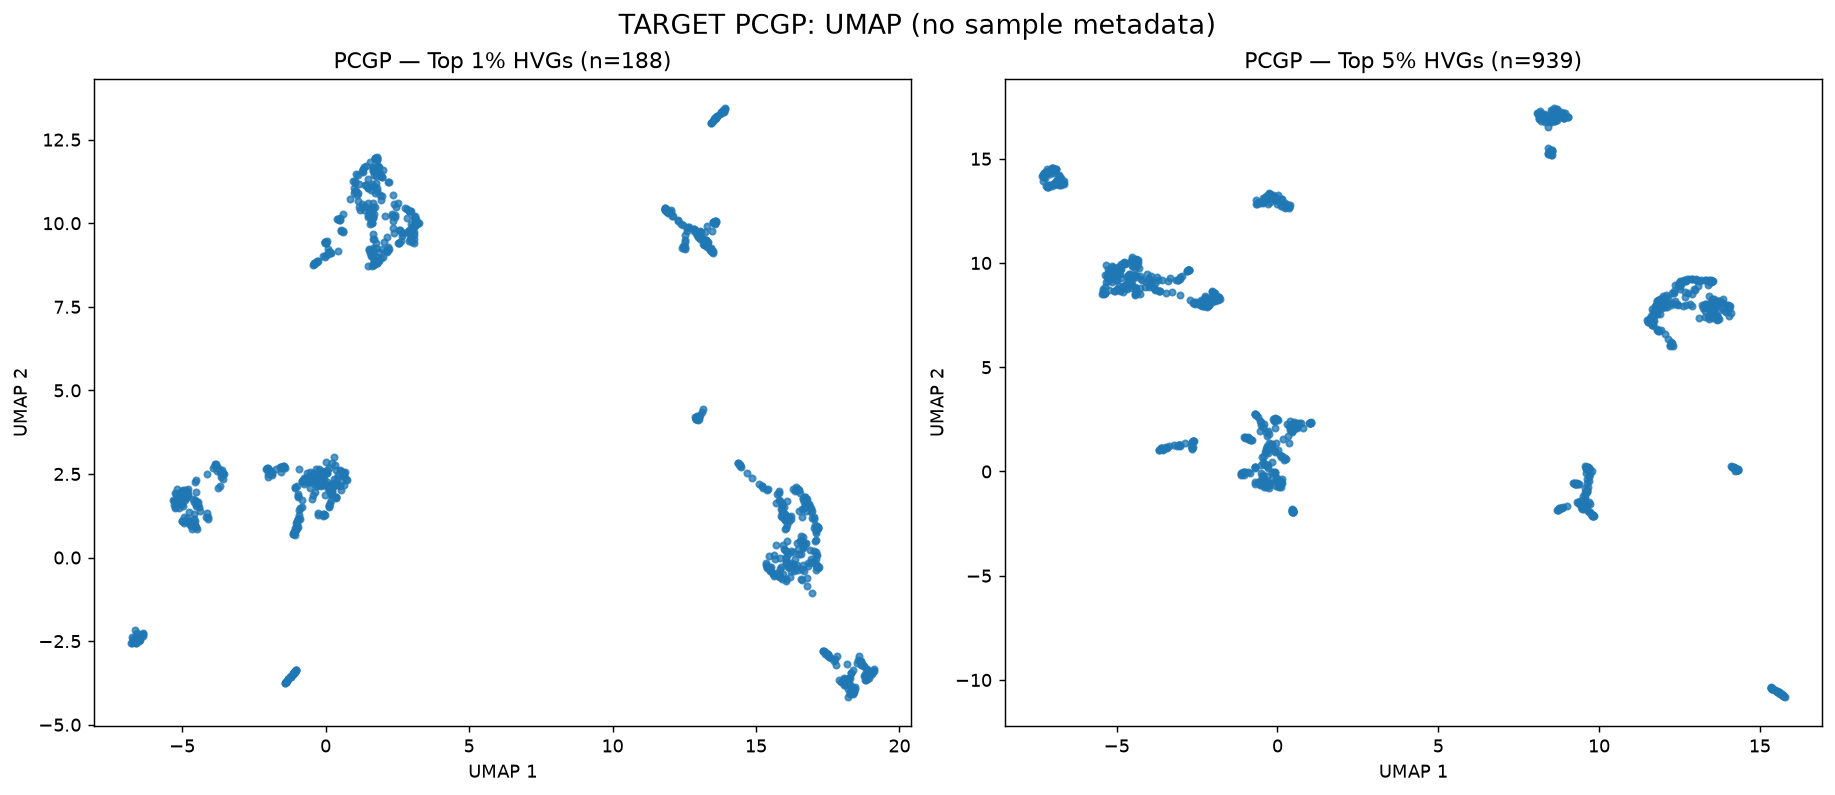

In [ ]:
pcgp_umap_top1 = run_umap(pcgp_log_cpm, pcgp_top1_idx, RANDOM_STATE)
pcgp_umap_top5 = run_umap(pcgp_log_cpm, pcgp_top5_idx, RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax, (pct, embedding, idx) in zip(axes, [
    ('1', pcgp_umap_top1, pcgp_top1_idx),
    ('5', pcgp_umap_top5, pcgp_top5_idx),
]):
    ax.scatter(embedding[:, 0], embedding[:, 1], s=12, alpha=0.75, rasterized=True)
    ax.set(title=f'PCGP — Top {pct}% HVGs (n={len(idx)})', xlabel='UMAP 1', ylabel='UMAP 2')
fig.suptitle('TARGET PCGP: UMAP (no sample metadata)', fontsize=15)
fig.savefig(PCGP_OUTPUT_DIR / 'PCGP_UMAP_top1_top5.png', dpi=300, bbox_inches='tight')
plt.show()


### Save coordinates now; overlay held-out metadata **later**

Save coordinates with exact sample IDs (`SJACT001_D`, etc.) so the professor can later provide a sample → diagnosis map. Keep the calculated UMAP coordinates unchanged when you later color them by diagnosis. Never use hidden metadata in the unsupervised fitting step.

In [ ]:
for pct, embedding in [('1', pcgp_umap_top1), ('5', pcgp_umap_top5)]:
    table = pcgp_sample_meta.copy()
    table['UMAP1'] = embedding[:, 0]
    table['UMAP2'] = embedding[:, 1]
    table.to_csv(
        PCGP_OUTPUT_DIR / f'pcgp_top{pct}pct_umap_coordinates.tsv',
        sep='\t', index=False
    )
print('PCGP results saved to:', PCGP_OUTPUT_DIR.resolve())

PCGP results saved to: /Users/rita/medgemma-fl/outputs/pcgp_umap


---

## Part III: DNA methylation 

In [23]:
METH_DIR = Path('/Users/rita/medgemma-fl/methyl')
METH_OUTPUT_DIR = METH_DIR.parent / 'outputs' / 'methylation_umap'
METH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METH_FILE_NAMES = None
METH_PLATFORMS = ('450K', 'EPIC')
METH_CHUNK_ROWS = 1500
METH_MIN_PROBE_COVERAGE = 0.95     # keep probes observed in >= 95% of samples
METH_MAX_SAMPLE_MISSING = 0.20     # stop if any sample has >20% missing CpGs
METH_RANDOM_STATE = 42

if not METH_DIR.is_dir():
    raise FileNotFoundError(
        f'Methylation folder not found: {METH_DIR}. Download the *_beta.txt '
        'files from DNAnexus and set METH_DIR to the correct local folder.'
    )

### Inventory the beta matrices

Only `*_beta.txt` files are included. The `*.samples` files in the screenshot are **not** used as diagnosis labels. Platform and project names below are inferred from filenames; confirm sample provenance before biological interpretation.

In [24]:
def inspect_methylation_file(path):
    name = path.name
    matched = re.search(r'_(450K|EPIC|27K)_beta\.txt$', name, flags=re.IGNORECASE)
    if matched is None:
        return None
    platform = matched.group(1).upper()
    project_match = re.search(r'(TARGET-[A-Z0-9-]+?)_+(?:450K|EPIC|27K)_beta\.txt$',
                              name, flags=re.IGNORECASE)
    project_hint = project_match.group(1).upper() if project_match else name
    with open(path, encoding='utf-8-sig') as handle:
        first_line = handle.readline().strip()
    # DNAnexus displays whitespace-aligned previews; the downloaded files
    # are usually TSV. Support whitespace-delimited exports as a fallback.
    separator = '\t' if '\t' in first_line else r'\s+'
    header = first_line.split('\t') if separator == '\t' else first_line.split()
    if len(header) < 5 or header[0].strip().lower() != 'targetid':
        raise ValueError(f'Expected TargetID + sample columns in {path.name}; found {header[:5]}')
    sample_names = [x.strip() for x in header[1:]]
    sample_ids = [re.sub(r'\.Ave_Beta$', '', x, flags=re.IGNORECASE)
                  for x in sample_names]
    if len(sample_names) != len(set(sample_names)):
        raise ValueError(f'Duplicate columns in {path.name}')
    return {
        'path': path, 'platform': platform, 'file_project': project_hint,
        'sep': separator, 'header': header, 'sample_names': sample_names,
        'sample_ids': sample_ids, 'n_samples': len(sample_names),
    }

meth_paths = sorted(p for p in METH_DIR.rglob('*_beta.txt') if p.is_file())
if METH_FILE_NAMES is not None:
    keep_names = set(METH_FILE_NAMES)
    meth_paths = [p for p in meth_paths if p.name in keep_names]
    missing_names = keep_names - {p.name for p in meth_paths}
    if missing_names:
        raise FileNotFoundError(f'Requested beta files not found: {sorted(missing_names)}')

meth_files = [inspect_methylation_file(p) for p in meth_paths]
meth_files = [f for f in meth_files if f is not None and f['platform'] in METH_PLATFORMS]
if not meth_files:
    raise FileNotFoundError(f'No recognized 450K/EPIC *_beta.txt files in {METH_DIR}')

meth_inventory = pd.DataFrame([{
    'filename': f['path'].name, 'platform': f['platform'],
    'file_project': f['file_project'], 'samples': f['n_samples'],
    'size_GiB': round(f['path'].stat().st_size / (1024**3), 3),
} for f in meth_files])
display(meth_inventory)

,filename,platform,file_project,samples,size_GiB
0,idat_sample_sheet_TARGET-ALL-P3__EPIC_beta.txt,EPIC,TARGET-ALL-P3,282,2.473
1,idat_sample_sheet_TARGET-AML__450k_beta.txt,450K,TARGET-AML,634,3.640
2,idat_sample_sheet_TARGET-CCSK__450k_beta.txt,450K,TARGET-CCSK,22,0.109
3,idat_sample_sheet_TARGET-NBL__450k_beta.txt,450K,TARGET-NBL,470,2.376
4,idat_sample_sheet_TARGET-OS__450k_beta.txt,450K,TARGET-OS,172,0.847
5,idat_sample_sheet_TARGET-RT__EPIC_beta.txt,EPIC,TARGET-RT,136,1.251
6,idat_sample_sheet_TARGET-WT__450k_beta.txt,450K,TARGET-WT,262,1.247


### Select variable CpG probes per platform 

The first pass calculates variance across *all samples in files from one platform*, applying a minimum nonmissing-data threshold. Within-platform files must have the **same CpG IDs in the same order**; otherwise this section stops rather than incorrectly matching rows. The second pass loads only the selected top 5% CpGs. The top 1% CpGs are a subset of the top 5% for the same platform.

Unlike RNA-seq counts, beta values already represent a fraction. Missing values are handled after selection by imputing the per-probe median for UMAP **only**; save original beta data separately for downstream methylation analysis.

In [25]:
def meth_iter_chunks(file_info):
    return iter(pd.read_csv(
        file_info['path'], sep=file_info['sep'], chunksize=METH_CHUNK_ROWS,
        low_memory=False, encoding='utf-8-sig',
        na_values=['NA', 'NaN', 'nan', ''],
    ))


def meth_numeric_matrix(chunk, file_info):
    ids = chunk.iloc[:, 0].astype(str).str.strip().to_numpy()
    if not np.all(np.char.startswith(ids.astype(str), 'cg')):
        # Some arrays also have non-cg control IDs. These are kept as long
        # as their IDs match across files; we do not assume they're genes.
        pass
    vals = chunk.iloc[:, 1:].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=np.float32)
    invalid = np.isfinite(vals) & ((vals < -1e-6) | (vals > 1 + 1e-6))
    if invalid.any():
        raise ValueError(f'Beta values outside [0, 1] in {file_info["path"].name}. '
                         'Verify that this is a beta-value file, not raw counts or M-values.')
    return ids, vals


def select_methylation_probes(platform_files):
    platform = platform_files[0]['platform']
    combined_sample_names = []
    combined_meta = []
    for f in platform_files:
        combined_sample_names.extend(f['sample_ids'])
        combined_meta.extend([{
            'sample_id': sid, 'original_column': col,
            'file_project': f['file_project'], 'platform': f['platform'],
            'source_file': f['path'].name,
        } for sid, col in zip(f['sample_ids'], f['sample_names'])])
    if len(combined_sample_names) != len(set(combined_sample_names)):
        raise ValueError(f'One or more sample IDs repeat within {platform} files. '
                         'Resolve duplicate arrays/samples before combining.')

    n_samples = len(combined_sample_names)
    sample_observed = np.zeros(n_samples, dtype=np.int64)
    n_probes = 0
    chunks_processed = 0
    summary_parts = []
    iterators = [meth_iter_chunks(f) for f in platform_files]

    for parts in zip_longest(*iterators, fillvalue=None):
        if any(p is None for p in parts):
            raise ValueError(f'Unequal CpG row counts in {platform} files. '
                             'Inspect platform/probe sets; run one file at a time or harmonize IDs first.')
        id0 = None
        values_parts = []
        for f, part in zip(platform_files, parts):
            ids, values = meth_numeric_matrix(part, f)
            if id0 is None:
                id0 = ids
            elif not np.array_equal(ids, id0):
                raise ValueError(f'CpG IDs or order differ within {platform}, e.g. file {f["path"].name}. '
                                 'Do not concatenate rows blindly. Try a single file with METH_FILE_NAMES.')
            values_parts.append(values)

        X = np.concatenate(values_parts, axis=1)
        finite = np.isfinite(X)
        sample_observed += finite.sum(axis=0)
        # Compute mean and variance across all samples at this CpG.
        n_valid = finite.sum(axis=1)
        cleaned = np.where(finite, X, 0.0).astype(np.float64)
        row_sum = cleaned.sum(axis=1)
        row_sumsq = np.square(cleaned).sum(axis=1)
        denom = np.maximum(n_valid, 1)
        variance = np.maximum(row_sumsq / denom - (row_sum / denom)**2, 0.0)
        summary_parts.append(pd.DataFrame({
            'cpg_id': id0, 'beta_variance': variance,
            'n_observed': n_valid,
        }))
        n_probes += len(id0)
        chunks_processed += 1
        if chunks_processed % 50 == 0:
            print(f'{platform}: scanned {n_probes:,} CpG rows')

    stats = pd.concat(summary_parts, ignore_index=True)
    if stats['cpg_id'].duplicated().any():
        raise ValueError(f'Duplicate CpG probe IDs found within {platform}; investigate before ranking.')

    min_observed = max(4, math.ceil(n_samples * METH_MIN_PROBE_COVERAGE))
    eligible = stats.loc[(stats['n_observed'] >= min_observed) &
                         (stats['beta_variance'] > 1e-10)].copy()
    if len(eligible) < 2:
        raise ValueError(f'{platform}: too few variable CpG probes passed coverage filtering.')

    eligible = eligible.sort_values('beta_variance', ascending=False)
    n1 = max(2, math.ceil(len(eligible) * 0.01))
    n5 = max(2, math.ceil(len(eligible) * 0.05))
    top5_table = eligible.iloc[:n5].copy().reset_index(drop=True)
    top1_table = top5_table.iloc[:n1].copy()
    sample_meta = pd.DataFrame(combined_meta)
    sample_meta['missing_fraction'] = 1 - sample_observed / max(n_probes, 1)
    bad = sample_meta['missing_fraction'] > METH_MAX_SAMPLE_MISSING
    if bad.any():
        display(sample_meta.loc[bad].head(15))
        raise ValueError(f'{platform}: {bad.sum()} samples exceed '
                         f'{METH_MAX_SAMPLE_MISSING:.0%} missing probes. '
                         'Check data quality before proceeding; do not silently impute those samples.')

    print(f'{platform}: {n_probes:,} CpGs, {n_samples:,} samples; '
          f'{len(eligible):,} eligible; top 1%={n1:,}, top 5%={n5:,}')
    return {
        'platform': platform, 'files': platform_files,
        'probe_stats': stats, 'top1_table': top1_table,
        'top5_table': top5_table, 'n1': n1, 'n5': n5,
        'sample_meta': sample_meta,
    }


def load_selected_methylation_beta(result):
    ids = result['top5_table']['cpg_id'].tolist()  # descending variance order
    requested = set(ids)
    matrices = []
    for file_info in result['files']:
        chunks = []
        for chunk in meth_iter_chunks(file_info):
            id_column = chunk.iloc[:, 0].astype(str).str.strip()
            keep = id_column.isin(requested)
            if keep.any():
                picked = chunk.loc[keep].copy()
                picked.iloc[:, 0] = id_column.loc[keep].to_numpy()
                picked = picked.set_index(picked.columns[0])
                values = picked.apply(pd.to_numeric, errors='coerce')
                chunks.append(values)
        if not chunks:
            raise ValueError(f'No selected probes in {file_info["path"].name}')
        selected = pd.concat(chunks, axis=0)
        if selected.index.duplicated().any():
            raise ValueError(f'Duplicate selected probes in {file_info["path"].name}')
        if not requested.issubset(set(selected.index)):
            missing = requested.difference(selected.index)
            raise ValueError(f'{file_info["path"].name} missing {len(missing)} selected CpGs')
        matrices.append(selected.reindex(ids).to_numpy(dtype=np.float32))

    beta = np.concatenate(matrices, axis=1)  # top5 CpGs x all platform samples
    if beta.shape[1] != len(result['sample_meta']):
        raise ValueError('Sample order mismatch in methylation matrix and metadata')
    # Median imputation for EDA visualization, not a clinical inference method.
    medians = np.nanmedian(beta, axis=1)
    if not np.isfinite(medians).all():
        raise ValueError('A selected CpG is missing across all samples')
    missing = np.where(~np.isfinite(beta))
    beta[missing] = medians[missing[0]]
    return beta

### Harmonize EPIC CpG IDs across files

The two EPIC files have **865,859 shared CpGs**. Calculate probe variance on the shared CpG set using sample-level values from both files. This aligns rows by ID rather than assuming equal row counts or order; then create **one joint EPIC UMAP**. The already successful 450K results are not affected.


In [26]:
# Harmonize files from the SAME methylation array platform by CpG ID.
# Designed for EPIC ALL-P3 + RT, whose CpG sets overlap but are not identical.
# Uses two streaming passes to avoid loading the full ~866K x samples matrix into RAM.

def select_methylation_probes_aligned(platform_files):
    platform = platform_files[0]['platform']
    if any(f['platform'] != platform for f in platform_files):
        raise ValueError('This function only combines files from the same platform.')

    combined_meta = [
        {
            'sample_id': sid, 'original_column': col,
            'file_project': f['file_project'], 'platform': f['platform'],
            'source_file': f['path'].name,
        }
        for f in platform_files
        for sid, col in zip(f['sample_ids'], f['sample_names'])
    ]
    sample_names = [row['sample_id'] for row in combined_meta]
    if len(sample_names) != len(set(sample_names)):
        raise ValueError('Duplicate sample IDs across platform files; resolve before combining.')

    # One-column read keeps the probe inventory small in memory.
    id_lists = []
    for f in platform_files:
        ids = pd.read_csv(
            f['path'], sep=f['sep'], usecols=[0], dtype=str,
            encoding='utf-8-sig',
        ).iloc[:, 0].str.strip()
        if ids.isna().any() or ids.duplicated().any():
            raise ValueError(f'Missing or duplicate CpG IDs in {f["path"].name}')
        id_lists.append(pd.Index(ids.to_numpy(), name='cpg_id'))

    # Preserve the first file's CpG order; restrict to the exact common IDs.
    common = id_lists[0]
    for ids in id_lists[1:]:
        common = common[common.isin(ids)]
    if len(common) < 2:
        raise ValueError(f'{platform}: too few common CpG probes to compare files.')

    print(f'{platform}: common CpGs = {len(common):,} '
          f'(intersection of {[len(ids) for ids in id_lists]})')

    n_probes = len(common)
    n_samples = len(sample_names)
    observed = np.zeros(n_probes, dtype=np.int32)
    sums = np.zeros(n_probes, dtype=np.float64)
    sums_sq = np.zeros(n_probes, dtype=np.float64)
    sample_observed = np.zeros(n_samples, dtype=np.int64)

    # Process EACH file independently. Do NOT zip its chunks with another file:
    # differing row counts/order would align unrelated CpGs.
    start_col = 0
    for f in platform_files:
        print(f'{platform}: scanning {f["path"].name}')
        for part in meth_iter_chunks(f):
            ids, vals = meth_numeric_matrix(part, f)
            positions = common.get_indexer(ids)
            keep = positions >= 0
            if not keep.any():
                continue
            positions = positions[keep]
            vals = vals[keep]
            finite = np.isfinite(vals)
            cleaned = np.where(finite, vals, 0).astype(np.float64)

            # Probe IDs have been checked unique within each file.
            observed[positions] += finite.sum(axis=1)
            sums[positions] += cleaned.sum(axis=1)
            sums_sq[positions] += np.square(cleaned).sum(axis=1)
            sample_observed[start_col:start_col + f['n_samples']] += finite.sum(axis=0)
        start_col += f['n_samples']

    if start_col != n_samples:
        raise ValueError('Sample order/count mismatch')

    denom = np.maximum(observed, 1)
    variance = np.maximum(sums_sq / denom - (sums / denom) ** 2, 0.0)
    stats = pd.DataFrame({
        'cpg_id': common.to_numpy(),
        'beta_variance': variance,
        'n_observed': observed,
    })
    min_observed = max(4, math.ceil(n_samples * METH_MIN_PROBE_COVERAGE))
    eligible = stats.loc[
        (stats['n_observed'] >= min_observed)
        & (stats['beta_variance'] > 1e-10)
    ].sort_values('beta_variance', ascending=False).copy()
    if len(eligible) < 2:
        raise ValueError(f'{platform}: too few variable CpGs passed coverage filtering.')

    n1 = max(2, math.ceil(len(eligible) * 0.01))
    n5 = max(2, math.ceil(len(eligible) * 0.05))
    top5_table = eligible.iloc[:n5].copy().reset_index(drop=True)
    top1_table = top5_table.iloc[:n1].copy()

    sample_meta = pd.DataFrame(combined_meta)
    sample_meta['missing_fraction'] = 1 - sample_observed / n_probes
    bad = sample_meta['missing_fraction'] > METH_MAX_SAMPLE_MISSING
    if bad.any():
        display(sample_meta.loc[bad].head(15))
        raise ValueError(f'{platform}: {bad.sum()} samples exceed '
                         f'{METH_MAX_SAMPLE_MISSING:.0%} missing CpGs.')

    print(f'{platform}: {n_probes:,} shared CpGs; {n_samples:,} samples; '
          f'{len(eligible):,} eligible CpGs; top 1%={n1:,}, top 5%={n5:,}')
    return {
        'platform': platform, 'files': platform_files,
        'probe_stats': stats, 'top1_table': top1_table,
        'top5_table': top5_table, 'n1': n1, 'n5': n5,
        'sample_meta': sample_meta,
    }


### Run separate 450K and harmonized joint EPIC UMAPs and save UMAP coordinates

This may take several minutes or longer depending on file sizes and your Mac's memory and disk. A separate UMAP is fitted for the top 1% and top 5% selected CpGs for each platform. Each dot is a methylation **sample/array**, not a CpG or a patient; multiple arrays can refer to one patient.

In [28]:
# Keep a previously completed 450K result if rerunning only this cell.
# If you change the input files/settings, run: meth_results = {} before this cell.
meth_results = globals().get('meth_results', {})
for platform in METH_PLATFORMS:
    platform_files = [f for f in meth_files if f['platform'] == platform]
    if not platform_files:
        print(f'{platform}: no matching files; skipping')
        continue
    if platform in meth_results:
        print(f'{platform}: already computed in this session; skipping')
        continue
    print(f'\n--- {platform} ({len(platform_files)} files) ---')
    res = (select_methylation_probes_aligned(platform_files)
           if platform == 'EPIC' and len(platform_files) > 1
           else select_methylation_probes(platform_files))
    beta_top5 = load_selected_methylation_beta(res)

    # run_umap_direct expects feature x sample; works for CpG beta as well.
    n1 = res['n1']
    res['umap1'] = run_umap(
        beta_top5, np.arange(n1), METH_RANDOM_STATE
    )
    res['umap5'] = run_umap(
        beta_top5, np.arange(res['n5']), METH_RANDOM_STATE
    )
    meth_results[platform] = res

    out_platform = METH_OUTPUT_DIR / platform
    out_platform.mkdir(parents=True, exist_ok=True)
    res['sample_meta'].to_csv(out_platform / 'sample_inventory.tsv', sep='\t', index=False)
    res['top1_table'].to_csv(out_platform / 'top1pct_variable_cpgs.tsv', sep='\t', index=False)
    res['top5_table'].to_csv(out_platform / 'top5pct_variable_cpgs.tsv', sep='\t', index=False)
    for pct, embedding in [('1', res['umap1']), ('5', res['umap5'])]:
        coordinates = res['sample_meta'].copy()
        coordinates['UMAP1'] = embedding[:, 0]
        coordinates['UMAP2'] = embedding[:, 1]
        coordinates.to_csv(out_platform / f'umap_top{pct}pct_coordinates.tsv', sep='\t', index=False)

if not meth_results:
    raise ValueError('No eligible methylation platforms were analyzed.')


--- 450K (5 files) ---
450K: scanned 75,000 CpG rows
450K: scanned 150,000 CpG rows
450K: scanned 225,000 CpG rows
450K: scanned 300,000 CpG rows
450K: scanned 375,000 CpG rows
450K: scanned 450,000 CpG rows
450K: 485,512 CpGs, 1,560 samples; 485,512 eligible; top 1%=4,856, top 5%=24,276
Direct UMAP input: 1560 samples × 4856 genes


/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Direct UMAP input: 1560 samples × 24276 genes


/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



--- EPIC (2 files) ---
EPIC: common CpGs = 865,859 (intersection of [866091, 866238])
EPIC: scanning idat_sample_sheet_TARGET-ALL-P3__EPIC_beta.txt
EPIC: scanning idat_sample_sheet_TARGET-RT__EPIC_beta.txt
EPIC: 865,859 shared CpGs; 418 samples; 865,859 eligible CpGs; top 1%=8,659, top 5%=43,293
Direct UMAP input: 418 samples × 8659 genes


/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Direct UMAP input: 418 samples × 43293 genes


/Users/rita/medgemma-fl/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Plot methylation UMAPs

There is one row per available platform (450K / EPIC) and two columns (top 1% / top 5% variable CpGs). Sample colors represent the **source project inferred from the filename** only; they are applied after UMAP and do not affect the embedding. A group label on a figure is not a confirmed diagnosis label.

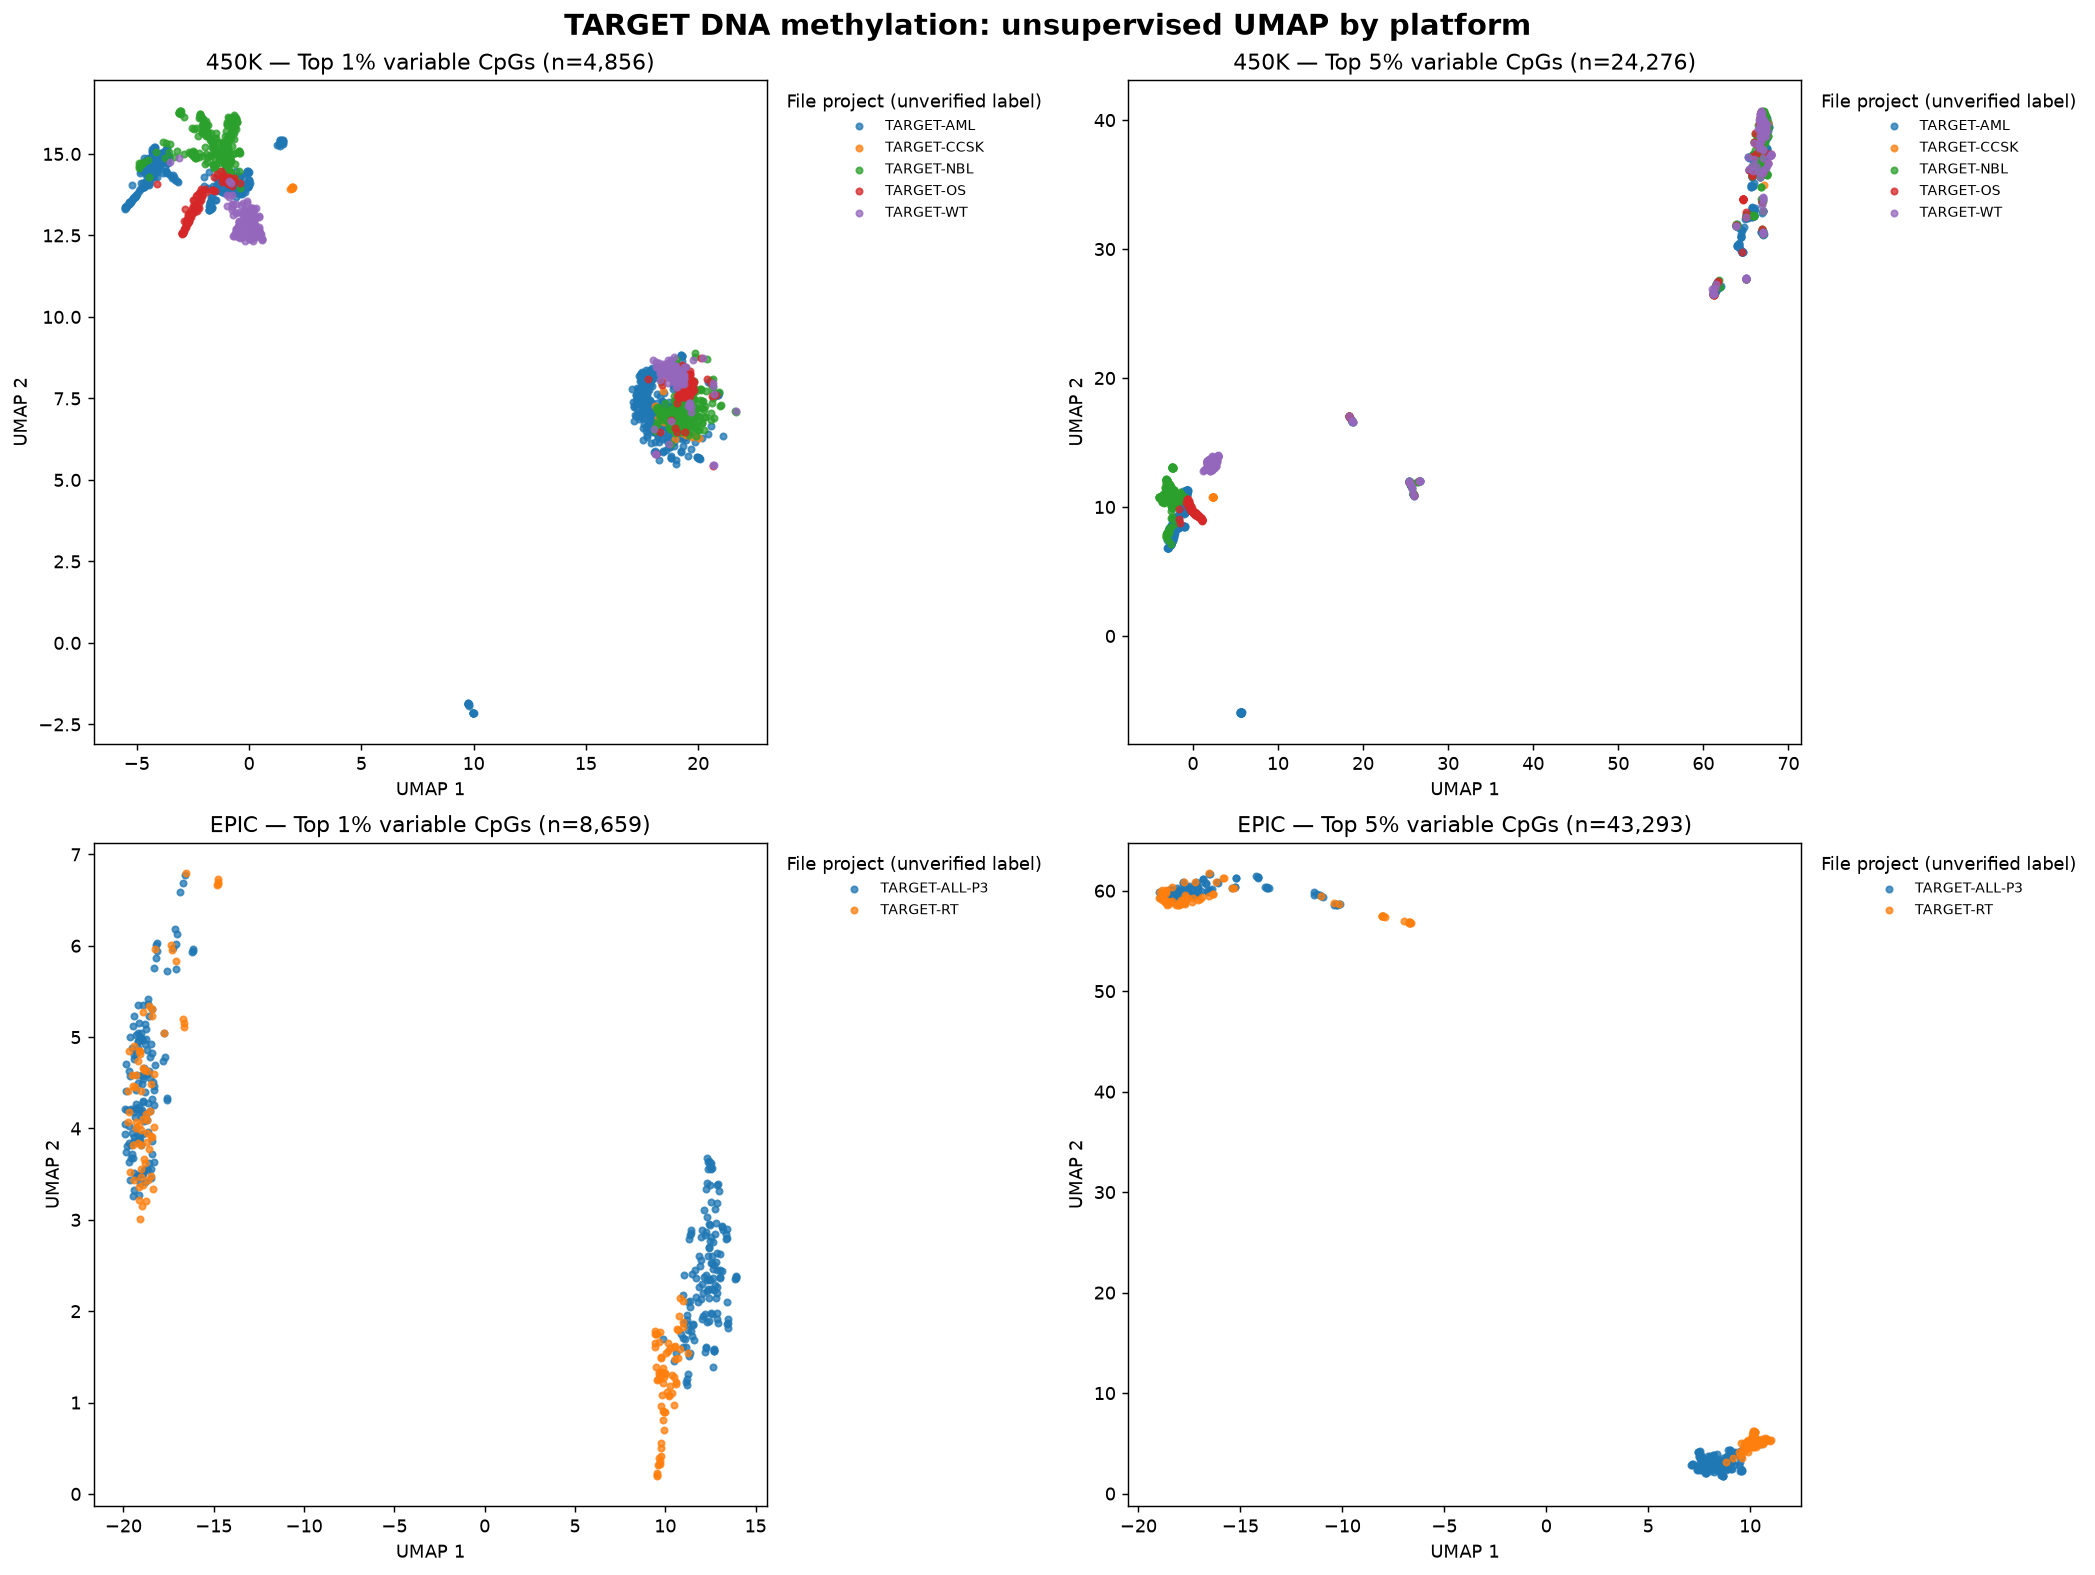

Saved methylation figures / sample coordinates / CpG lists to: /Users/rita/medgemma-fl/outputs/methylation_umap


In [ ]:
platforms_plotted = list(meth_results)
fig, axes = plt.subplots(
    len(platforms_plotted), 2, figsize=(16, 6 * len(platforms_plotted)),
    squeeze=False, constrained_layout=True,
)
for row, platform in enumerate(platforms_plotted):
    res = meth_results[platform]
    project_values = res['sample_meta']['file_project'].astype(str).to_numpy()
    projects = sorted(set(project_values))
    for col, (pct, embedding, top_table) in enumerate([
        ('1', res['umap1'], res['top1_table']),
        ('5', res['umap5'], res['top5_table']),
    ]):
        ax = axes[row, col]
        for project in projects:
            mask = project_values == project
            ax.scatter(embedding[mask, 0], embedding[mask, 1],
                       s=12, alpha=0.75, label=project, rasterized=True)
        ax.set_title(f'{platform} — Top {pct}% variable CpGs (n={len(top_table):,})')
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        if len(projects) > 1:
            ax.legend(title='File project (unverified label)',
                      loc='upper left', bbox_to_anchor=(1.01, 1),
                      frameon=False, fontsize=8)
fig.suptitle('DNA methylation: UMAP by platform',
             fontsize=16, fontweight='bold')
fig.savefig(METH_OUTPUT_DIR / 'TARGET_methylation_UMAP_platform_top1_top5.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved methylation figures / sample coordinates / CpG lists to:', METH_OUTPUT_DIR.resolve())